In [1]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import wilcoxon

RUN_ROOT = Path("qseek")                      # folder that contains the run directories
RUNS = {                                      # (model, stage) -> Qseek run directory
    ("Global", "pass1"):           "kl2024_global_pass1",
    ("Global", "SSST"):            "kl2024_global_ssst",
    ("Local-scratch", "pass1"):    "kl2024_scratch_pass1",
    ("Local-scratch", "SSST"):     "kl2024_scratch_ssst",
    ("Local-fine-tuned", "pass1"): "kl2024_transfer_pass1",
    ("Local-fine-tuned", "SSST"):  "kl2024_transfer_ssst",
}
MODELS = ["Global", "Local-scratch", "Local-fine-tuned"]
COLORS = {"Global": "#2E6F95", "Local-scratch": "#4C9A5B", "Local-fine-tuned": "#D9782D"}
LS = {"pass1": "--", "SSST": "-"}

In [2]:
T0, T1 = pd.Timestamp("2024-01-01", tz="UTC"), pd.Timestamp("2025-01-01", tz="UTC")
# Qseek search volume: copy from the octree block of the kl2024 configs
CENTER_LAT, CENTER_LON = 50.22, 12.35
EAST_KM, NORTH_KM = 38.0, 50.0                # half-widths of the volume
DEPTH_KM = (0.0, 20.0)
# Association rule, fixed before looking at results
DT_MAX_S, DIST_MAX_KM = 2.0, 5.0
N_BOOT = 2000
OUT = Path("figures/catalogue"); OUT.mkdir(parents=True, exist_ok=True)
EPOCH = pd.Timestamp("1970-01-01", tz="UTC")


In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))

def local_xy_km(lat, lon):
    return ((lon - CENTER_LON) * 111.195 * np.cos(np.radians(CENTER_LAT)),
            (lat - CENTER_LAT) * 111.195)

def load_qseek(run_dir):
    df = pd.read_csv(RUN_ROOT / run_dir / "csv" / "detections.csv")
    df["time"] = pd.to_datetime(df["time"], utc=True, format="ISO8601")
    if df["depth"].abs().median() > 100:      # Qseek depth in metres -> km
        df["depth"] = df["depth"] / 1000
    return df[(df.time >= T0) & (df.time < T1)].reset_index(drop=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(OUT / f"{name}.png", dpi=300, bbox_inches="tight")
    plt.savefig(OUT / f"{name}.pdf", bbox_inches="tight")
    plt.show()

cats = {k: load_qseek(v) for k, v in RUNS.items()}
for k, c in cats.items():
    print(f"{k[0]:18s} {k[1]:6s} {len(c):7d} events")

Global             pass1    13284 events
Global             SSST     15254 events
Local-scratch      pass1    12443 events
Local-scratch      SSST     16353 events
Local-fine-tuned   pass1     3744 events
Local-fine-tuned   SSST      4975 events


In [4]:
import seisbench.data as sbd

meta = sbd.BohemiaSaxony().metadata
man = (meta[["source_origin_time", "source_latitude_deg", "source_longitude_deg",
             "source_depth_km", "source_magnitude"]]
       .drop_duplicates("source_origin_time")
       .set_axis(["time", "lat", "lon", "depth", "mag"], axis=1))
man["time"] = pd.to_datetime(man["time"], utc=True, format="ISO8601")
man = man[(man.time >= T0) & (man.time < T1)]

e, n = local_xy_km(man.lat, man.lon)
inside = (e.abs() <= EAST_KM) & (n.abs() <= NORTH_KM) & man.depth.between(*DEPTH_KM)
print(f"Manual events 2024: {len(man)}, inside Qseek volume: {inside.sum()}")
man = man[inside].reset_index(drop=True)

2026-09-30 19:38:35,019 | seisbench | WARNING | The class BenchmarkDataset is deprecated. Use WaveformBenchmarkDataset instead.
2026-09-30 19:38:36,027 | seisbench | WARNING | Output component order not specified, defaulting to 'ZNE'.


Manual events 2024: 1884, inside Qseek volume: 1848


In [8]:
def associate(man, ml, dt_max=DT_MAX_S, d_max=DIST_MAX_KM):
    """One-to-one matching, cheapest pairs first; cost = |dt|/dt_max + dist/d_max."""
    # ponytail: greedy, not Hungarian; identical result unless events are < 2 s and < 5 km apart
    tm = (man.time - EPOCH).dt.total_seconds().to_numpy()
    tq = (ml.time - EPOCH).dt.total_seconds().to_numpy()
    order = np.argsort(tq)
    lo = np.searchsorted(tq[order], tm - dt_max)
    hi = np.searchsorted(tq[order], tm + dt_max, side="right")
    i = np.repeat(np.arange(len(tm)), hi - lo)
    j = order[np.concatenate([np.arange(a, b) for a, b in zip(lo, hi)] + [np.empty(0, int)])]
    d = haversine_km(man.lat.values[i], man.lon.values[i], ml.lat.values[j], ml.lon.values[j])
    keep = d <= d_max
    i, j, d = i[keep], j[keep], d[keep]
    dt = tq[j] - tm[i]
    used_i, used_j, rows = set(), set(), []
    for k in np.argsort(np.abs(dt) / dt_max + d / d_max, kind="stable"):
        if i[k] not in used_i and j[k] not in used_j:
            used_i.add(i[k]); used_j.add(j[k]); rows.append(k)
    r = np.array(rows, dtype=int)
    return pd.DataFrame({"i_man": i[r], "j_ml": j[r], "dt_s": dt[r], "dh_km": d[r],
                         "dz_km": ml.depth.values[j[r]] - man.depth.values[i[r]]})

_m = pd.DataFrame({"time": pd.to_datetime(["2024-01-01T00:00:00Z", "2024-01-01T00:00:01Z", "2024-01-01T01:00:00Z"], format="ISO8601"),
                   "lat": [50.2, 50.2, 50.3], "lon": [12.4] * 3, "depth": [8.0] * 3})
_q = _m.assign(time=pd.to_datetime(["2024-01-01T00:00:00.2Z", "2024-01-01T00:00:01.1Z", "2024-01-01T01:00:00Z"], format="ISO8601"),
               lat=[50.2, 50.2, 50.5])

assert sorted(zip(associate(_m, _q).i_man, associate(_m, _q).j_ml)) == [(0, 0), (1, 1)]
print("associate: self-check passed")

matches = {k: associate(man, c) for k, c in cats.items()}


rows = []
for (model, stage), m in matches.items():
    n_ml, n_man, tp = len(cats[(model, stage)]), len(man), len(m)
    rows.append(dict(model=model, stage=stage, n_ml=n_ml, n_manual=n_man, matched=tp,
                     ml_only=n_ml - tp, missed=n_man - tp,
                     recall=tp / n_man, precision_lb=tp / max(n_ml, 1), f1=2 * tp / (n_man + n_ml),
                     med_dh_km=m.dh_km.median(), med_abs_dz_km=m.dz_km.abs().median(),
                     med_abs_dt_s=m.dt_s.abs().median()))
summary = pd.DataFrame(rows).set_index(["model", "stage"])
summary.round(3)

associate: self-check passed


n_ml  n_manual  matched  ml_only  missed  recall  \
model            stage                                                      
Global           pass1  13284      1848     1489    11795     359   0.806   
                 SSST   15254      1848     1517    13737     331   0.821   
Local-scratch    pass1  12443      1848     1594    10849     254   0.863   
                 SSST   16353      1848     1657    14696     191   0.897   
Local-fine-tuned pass1   3744      1848     1030     2714     818   0.557   
                 SSST    4975      1848     1130     3845     718   0.611   

                        precision_lb     f1  med_dh_km  med_abs_dz_km  \
model            stage                                                  
Global           pass1         0.112  0.197      0.445          0.498   
                 SSST          0.099  0.177      0.382          0.415   
Local-scratch    pass1         0.128  0.223      0.462          0.392   
                 SSST          0.101  0.182      0.425          0.368   
Local-fine-tuned pass1         0.275  0.368      0.330          0.244   
                 SSST          0.227  0.331      0.236          0.251   

                        med_abs_dt_s  
model            stage                
Global           pass1          0.40  
                 SSST           0.42  
Local-scratch    pass1          0.41  
                 SSST           0.43  
Local-fine-tuned pass1          0.43  
                 SSST           0.45

In [ ]:
w0 = pd.Timestamp(wk.start_time, tz="UTC"); w1 = w0 + pd.Timedelta(days=7)
week_cats = {k: c[c.time.between(w0, w1, inclusive="left")].reset_index(drop=True)
             for k, c in cats.items() if k[1] == "pass1"}
week_cats[("Fine-tuned ZNE", "pass1")] = load_qseek("kl2024_transfer_zne_week_pass1")
man_w = man[man.time.between(w0, w1, inclusive="left")].reset_index(drop=True)

rows = []
for k, c in week_cats.items():
    m = associate(man_w, c)
    rows.append(dict(model=k[0], n_ml=len(c), n_manual=len(man_w), matched=len(m),
                     recall=len(m) / len(man_w), median_rms=c["rms"].median() if "rms" in c else np.nan))
pd.DataFrame(rows).set_index("model").round(3)

scratch                   P=  278  S=  628
fine-tuned ENZ (as run)   P=  348  S=  560
fine-tuned ZNE (fixed)    P=  386  S=  690


In [9]:
days = pd.date_range(T0, T1, freq="D", inclusive="left")
def per_day(times):
    return times.dt.floor("D").value_counts().reindex(days, fill_value=0).to_numpy()

n_man_d = per_day(man.time)
per_cat = {k: (per_day(man.time.iloc[m.i_man.values]), per_day(cats[k].time)) for k, m in matches.items()}
idx = np.random.default_rng(42).integers(0, len(days), size=(N_BOOT, len(days)))  # same days for all -> paired

boot = {}
for k, (tp_d, ml_d) in per_cat.items():
    tp, nm, nq = tp_d[idx].sum(1), n_man_d[idx].sum(1), ml_d[idx].sum(1)
    boot[k] = pd.DataFrame({"recall": tp / nm, "precision_lb": tp / np.maximum(nq, 1), "f1": 2 * tp / (nm + nq)})

ci = pd.DataFrame({k: {f"{met}_lo": np.percentile(b[met], 2.5) for met in b} |
                      {f"{met}_hi": np.percentile(b[met], 97.5) for met in b} for k, b in boot.items()}).T
display(ci.round(3))

def diff_ci(a, b, met):
    d = boot[a][met] - boot[b][met]
    return pd.Series({"diff": summary.loc[a, met] - summary.loc[b, met],
                      "lo": np.percentile(d, 2.5), "hi": np.percentile(d, 97.5)})

pairs = [(("Local-fine-tuned", "SSST"), ("Global", "SSST")),
         (("Local-scratch", "SSST"), ("Global", "SSST")),
         (("Local-fine-tuned", "SSST"), ("Local-scratch", "SSST"))] + \
        [((m, "SSST"), (m, "pass1")) for m in MODELS]
diffs = pd.DataFrame({f"{a[0]}|{a[1]} − {b[0]}|{b[1]} [{met}]": diff_ci(a, b, met)
                      for a, b in pairs for met in ["recall", "precision_lb", "f1"]}).T
diffs["significant"] = (diffs.lo > 0) | (diffs.hi < 0)
diffs.round(3)

recall_lo  precision_lb_lo  f1_lo  recall_hi  \
Global           pass1      0.774            0.098  0.174      0.835   
                 SSST       0.790            0.086  0.155      0.847   
Local-scratch    pass1      0.839            0.109  0.194      0.882   
                 SSST       0.879            0.086  0.156      0.913   
Local-fine-tuned pass1      0.503            0.240  0.334      0.608   
                 SSST       0.560            0.200  0.303      0.660   

                        precision_lb_hi  f1_hi  
Global           pass1            0.132  0.226  
                 SSST             0.118  0.206  
Local-scratch    pass1            0.155  0.263  
                 SSST             0.125  0.219  
Local-fine-tuned pass1            0.317  0.403  
                 SSST             0.262  0.364

,diff,lo,hi,significant
Local-fine-tuned|SSST − Global|SSST [recall],-0.209,-0.245,-0.176,True
Local-fine-tuned|SSST − Global|SSST [precision_lb],0.128,0.110,0.149,True
Local-fine-tuned|SSST − Global|SSST [f1],0.154,0.132,0.173,True
Local-scratch|SSST − Global|SSST [recall],0.076,0.056,0.100,True
Local-scratch|SSST − Global|SSST [precision_lb],0.002,-0.003,0.010,False
Local-scratch|SSST − Global|SSST [f1],0.005,-0.003,0.017,False
Local-fine-tuned|SSST − Local-scratch|SSST [recall],-0.285,-0.329,-0.246,True
Local-fine-tuned|SSST − Local-scratch|SSST [precision_lb],0.126,0.108,0.145,True
Local-fine-tuned|SSST − Local-scratch|SSST [f1],0.149,0.123,0.169,True
Global|SSST − Global|pass1 [recall],0.015,0.005,0.025,True


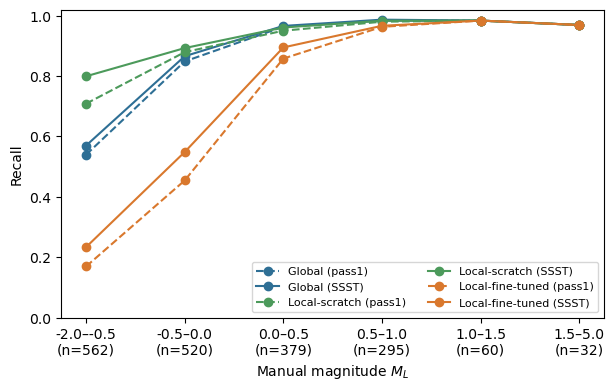

In [10]:
bins = [-2, -0.5, 0, 0.5, 1, 1.5, 5]
mbin = pd.cut(man.mag, bins)
fig, ax = plt.subplots(figsize=(7, 4))
for (model, stage), m in matches.items():
    hit = np.zeros(len(man), bool); hit[m.i_man] = True
    rec = pd.Series(hit).groupby(mbin.values, observed=False).mean()
    ax.plot(range(len(rec)), rec.values, LS[stage], marker="o", color=COLORS[model], label=f"{model} ({stage})")
counts = mbin.value_counts(sort=False)
ax.set_xticks(range(len(counts)), [f"{iv.left}–{iv.right}\n(n={c})" for iv, c in counts.items()])
ax.set(xlabel="Manual magnitude $M_L$", ylabel="Recall", ylim=(0, 1.02))
ax.legend(fontsize=8, ncol=2)

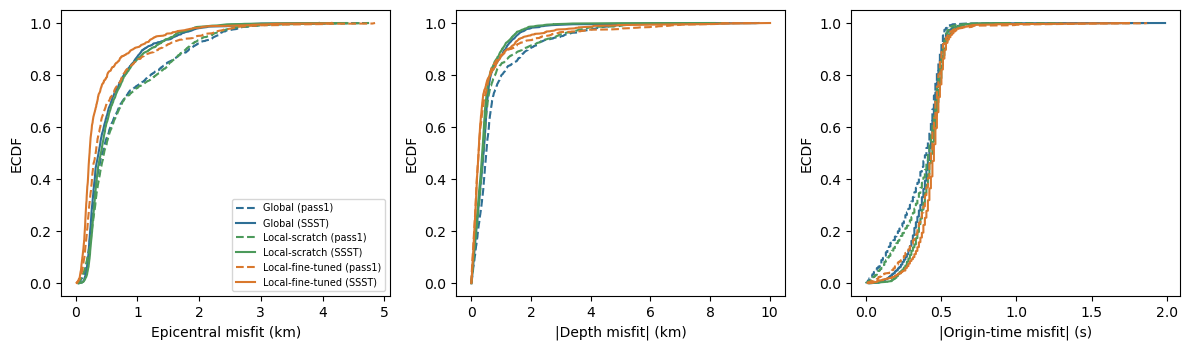

,model,metric,n_paired,median_pass1,median_ssst,wilcoxon_p
0,Global,epicentral |Δ| (km),1465,0.4320,0.3711,0.0000
1,Global,|Δ depth| (km),1465,0.4970,0.4101,0.0000
2,Global,|Δ origin time| (s),1465,0.4000,0.4200,0.0000
3,Local-scratch,epicentral |Δ| (km),1581,0.4605,0.4089,0.0000
4,Local-scratch,|Δ depth| (km),1581,0.3921,0.3646,0.0000
5,Local-scratch,|Δ origin time| (s),1581,0.4100,0.4400,0.0000
6,Local-fine-tuned,epicentral |Δ| (km),1010,0.3224,0.2261,0.0000
7,Local-fine-tuned,|Δ depth| (km),1010,0.2409,0.2411,0.7598
8,Local-fine-tuned,|Δ origin time| (s),1010,0.4300,0.4500,0.0000


In [11]:
rows = []
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for model in MODELS:
    a = matches[(model, "pass1")].set_index("i_man")
    b = matches[(model, "SSST")].set_index("i_man")
    common = a.index.intersection(b.index)
    for col, label in [("dh_km", "epicentral |Δ| (km)"), ("dz_km", "|Δ depth| (km)"), ("dt_s", "|Δ origin time| (s)")]:
        x, y = a.loc[common, col].abs(), b.loc[common, col].abs()
        rows.append(dict(model=model, metric=label, n_paired=len(common),
                         median_pass1=x.median(), median_ssst=y.median(),
                         wilcoxon_p=wilcoxon(x, y).pvalue if len(common) > 10 else np.nan))
    for ax, col in zip(axes, ["dh_km", "dz_km", "dt_s"]):
        for stage, df in [("pass1", a), ("SSST", b)]:
            v = np.sort(df.loc[common, col].abs().values)
            ax.plot(v, np.arange(1, len(v) + 1) / len(v), LS[stage], color=COLORS[model], label=f"{model} ({stage})")
for ax, t in zip(axes, ["Epicentral misfit (km)", "|Depth misfit| (km)", "|Origin-time misfit| (s)"]):
    ax.set(xlabel=t, ylabel="ECDF")
axes[0].legend(fontsize=7)
savefig("ssst_vs_pass1_location_ecdf")
ssst_effect = pd.DataFrame(rows)
ssst_effect.to_csv(OUT / "ssst_vs_pass1_paired.csv", index=False)
ssst_effect.round(4)

In [12]:
qcols = [c for c in ["semblance", "n_picks", "n_stations", "uncertainty_horizontal",
                     "uncertainty_vertical", "rms"] if c in cats[("Global", "SSST")].columns]
print("available:", qcols, "| all columns:", list(cats[("Global", "SSST")].columns))
pd.DataFrame({k: c[qcols].median() for k, c in cats.items()}).T.round(3)

available: ['semblance', 'n_picks', 'n_stations', 'uncertainty_horizontal', 'uncertainty_vertical', 'rms'] | all columns: ['time', 'lat', 'lon', 'depth', 'east_shift', 'north_shift', 'distance_border', 'semblance', 'azimuthal_coverage', 'n_stations', 'n_picks', 'rms', 'uncertainty_horizontal', 'uncertainty_vertical', 'ML-webnet-western-bohemia', 'ML-error-webnet-western-bohemia', 'ML-n-stations-webnet-western-bohemia', 'WKT_geom']


semblance  n_picks  n_stations  \
Global           pass1      0.386     30.0        58.0   
                 SSST       0.434     27.0        59.0   
Local-scratch    pass1      0.379     34.0        59.0   
                 SSST       0.421     29.0        59.0   
Local-fine-tuned pass1      0.322     43.0        58.0   
                 SSST       0.365     39.0        58.0   

                        uncertainty_horizontal  uncertainty_vertical    rms  
Global           pass1                 182.217                531.25  0.305  
                 SSST                  125.000                406.25  0.296  
Local-scratch    pass1                 159.344                468.75  0.181  
                 SSST                   98.821                343.75  0.136  
Local-fine-tuned pass1                 156.250                406.25  0.569  
                 SSST                   98.821                343.75  0.587

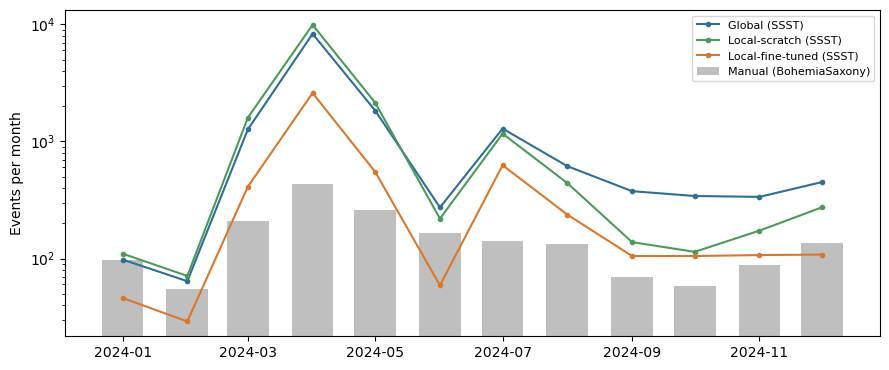

In [13]:
fig, ax = plt.subplots(figsize=(9, 3.8))
mm = man.time.dt.tz_convert(None).dt.to_period("M").value_counts().sort_index()
ax.bar(mm.index.to_timestamp(), mm.values, width=20, color="0.75", label="Manual (BohemiaSaxony)")
for model in MODELS:
    c = cats[(model, "SSST")].time.dt.tz_convert(None).dt.to_period("M").value_counts().sort_index()
    ax.plot(c.index.to_timestamp(), c.values, "-o", ms=3, color=COLORS[model], label=f"{model} (SSST)")
ax.set(ylabel="Events per month", yscale="log")
ax.legend(fontsize=8)
savefig("monthly_counts")

In [17]:
STAGES = ["pass1", "SSST"]
KEYS = [(m, s) for m in MODELS for s in STAGES]
SHORT = {"Global": "Global", "Local-scratch": "Scratch", "Local-fine-tuned": "Fine-tuned"}
KM_E = 111.195 * np.cos(np.radians(CENTER_LAT))
naive = lambda s: s.dt.tz_convert(None)          # matplotlib prefers tz-naive datetimes

def hits(k):
    """Boolean mask over manual events: found by catalogue k?"""
    h = np.zeros(len(man), bool); h[matches[k].i_man.values] = True
    return h

def mag_col(df):
    c = [c for c in df.columns if c.lower().startswith("ml") and "err" not in c.lower()]
    return c[0] if c else None

for k, m in matches.items():                      # signed epicentre offsets, Qseek − manual
    c, i, j = cats[k], m.i_man.values, m.j_ml.values
    m["dE_km"] = (c.lon.values[j] - man.lon.values[i]) * KM_E
    m["dN_km"] = (c.lat.values[j] - man.lat.values[i]) * 111.195
print("Qseek magnitude column:", mag_col(cats[("Global", "SSST")]))

Qseek magnitude column: ML-webnet-western-bohemia


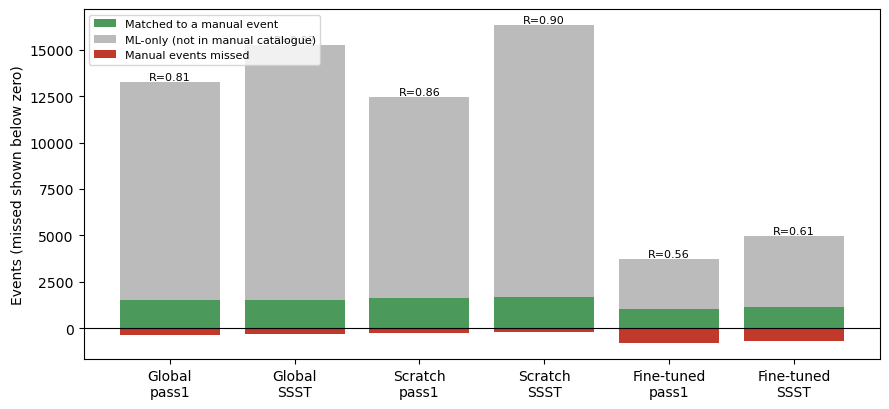

In [18]:
s = summary.loc[KEYS]
x = np.arange(len(KEYS))
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(x, s.matched, color="#4C9A5B", label="Matched to a manual event")
ax.bar(x, s.ml_only, bottom=s.matched, color="#BBBBBB", label="ML-only (not in manual catalogue)")
ax.bar(x, -s.missed, color="#C0392B", label="Manual events missed")
for xi, (_, r) in zip(x, s.iterrows()):
    ax.text(xi, r.matched + r.ml_only, f"R={r.recall:.2f}", ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x, [f"{SHORT[m]}\n{st}" for m, st in KEYS])
ax.set_ylabel("Events (missed shown below zero)")
ax.legend(fontsize=8, loc="upper left")
savefig("fig_c1_event_outcomes")

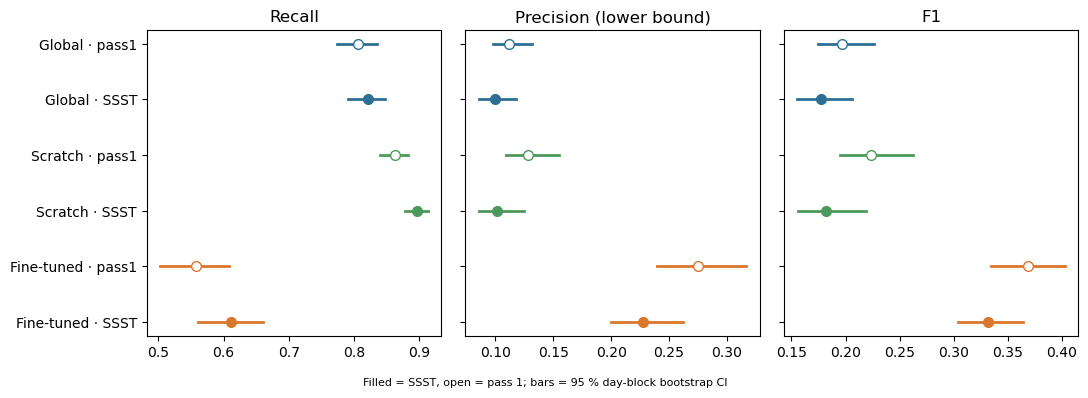

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), sharey=True)
for ax, met, title in zip(axes, ["recall", "precision_lb", "f1"], ["Recall", "Precision (lower bound)", "F1"]):
    for y, k in enumerate(KEYS):
        ax.plot([ci.loc[k, f"{met}_lo"], ci.loc[k, f"{met}_hi"]], [y, y], color=COLORS[k[0]], lw=2)
        ax.plot(summary.loc[k, met], y, "o", ms=7, color=COLORS[k[0]],
                mfc=COLORS[k[0]] if k[1] == "SSST" else "white")
    ax.set_title(title)
axes[0].set_yticks(range(len(KEYS)), [f"{SHORT[m]} · {s}" for m, s in KEYS])
axes[0].invert_yaxis()
fig.text(0.5, -0.03, "Filled = SSST, open = pass 1; bars = 95 % day-block bootstrap CI", ha="center", fontsize=8)
savefig("fig_c2_ci_forest")

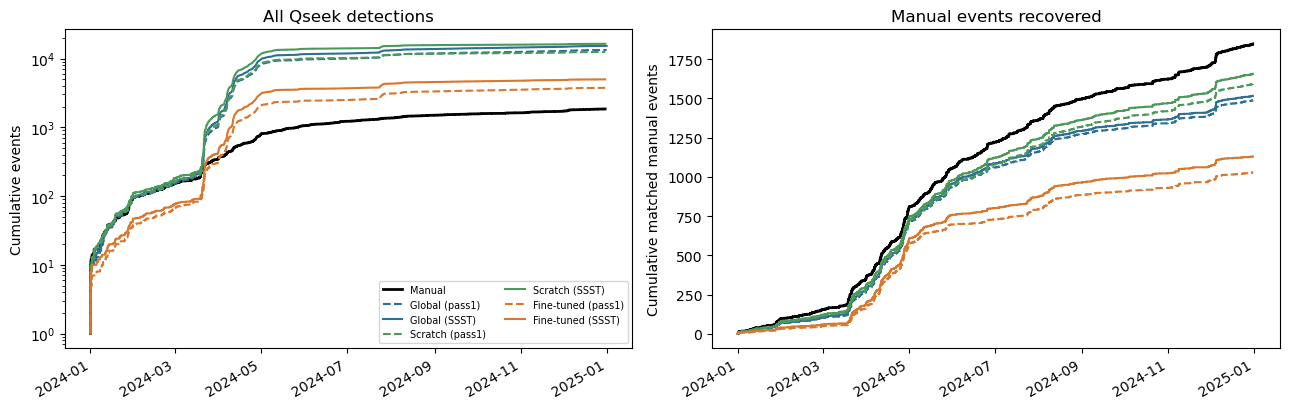

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharex=True)
tman = naive(man.time.sort_values())
for ax in axes:
    ax.step(tman, np.arange(1, len(tman) + 1), color="k", lw=2, label="Manual")
for k in KEYS:
    t = naive(cats[k].time.sort_values())
    axes[0].step(t, np.arange(1, len(t) + 1), LS[k[1]], color=COLORS[k[0]], label=f"{SHORT[k[0]]} ({k[1]})")
    tm = naive(man.time[hits(k)].sort_values())
    axes[1].step(tm, np.arange(1, len(tm) + 1), LS[k[1]], color=COLORS[k[0]])
axes[0].set(title="All Qseek detections", ylabel="Cumulative events", yscale="log")
axes[1].set(title="Manual events recovered", ylabel="Cumulative matched manual events")
axes[0].legend(fontsize=7, ncol=2)
fig.autofmt_xdate()
savefig("fig_c3_cumulative")

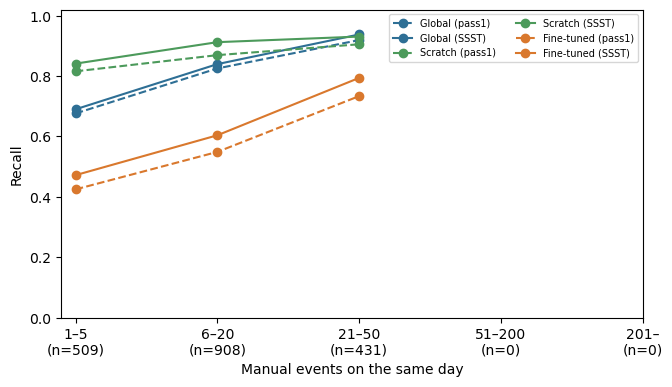

In [25]:
day = man.time.dt.floor("D")
rate = day.map(day.value_counts())                          # manual events on that event's day
rbin = pd.cut(rate, [0, 5, 20, 50, 200, np.inf])
fig, ax = plt.subplots(figsize=(7.5, 4))
for k in KEYS:
    rec = pd.Series(hits(k)).groupby(rbin.values, observed=False).mean()
    ax.plot(range(len(rec)), rec.values, LS[k[1]], marker="o", color=COLORS[k[0]], label=f"{SHORT[k[0]]} ({k[1]})")
cnt = rbin.value_counts(sort=False)
ax.set_xticks(range(len(cnt)), [f"{int(iv.left)+1}–{'' if np.isinf(iv.right) else int(iv.right)}\n(n={n})" for iv, n in cnt.items()])
ax.set(xlabel="Manual events on the same day", ylabel="Recall", ylim=(0, 1.02))
ax.legend(fontsize=7, ncol=2)

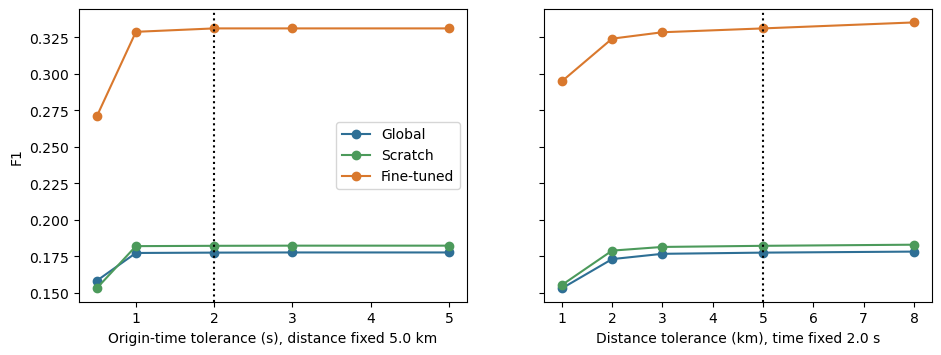

In [26]:
dts, dds = [0.5, 1, 2, 3, 5], [1, 2, 3, 5, 8]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for model in MODELS:
    c = cats[(model, "SSST")]
    f1 = lambda dt, dd: 2 * len(associate(man, c, dt, dd)) / (len(man) + len(c))
    axes[0].plot(dts, [f1(t, DIST_MAX_KM) for t in dts], "-o", color=COLORS[model], label=SHORT[model])
    axes[1].plot(dds, [f1(DT_MAX_S, d) for d in dds], "-o", color=COLORS[model])
axes[0].axvline(DT_MAX_S, color="k", ls=":"); axes[1].axvline(DIST_MAX_KM, color="k", ls=":")
axes[0].set(xlabel=f"Origin-time tolerance (s), distance fixed {DIST_MAX_KM} km", ylabel="F1")
axes[1].set(xlabel=f"Distance tolerance (km), time fixed {DT_MAX_S} s")
axes[0].legend()